# **Welcome to this Notebook on Interactive Training of Random Forest for Titanic Dataset!!**

# If you like my work don't forget to Upvote!

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [2]:
%matplotlib inline
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
import pandas as pd
plt.style.use("ggplot")
warnings.simplefilter("ignore")

In [3]:
df_train = pd.read_csv('/kaggle/input/titanic/train.csv')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_test = pd.read_csv('/kaggle/input/titanic/test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


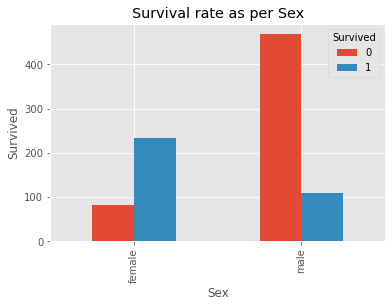

In [6]:
pd.crosstab(df_train.Sex ,df_train.Survived).plot(kind='bar')
plt.title('Survival rate as per Sex')
plt.xlabel('Sex')
plt.ylabel('Survived')
plt.show()

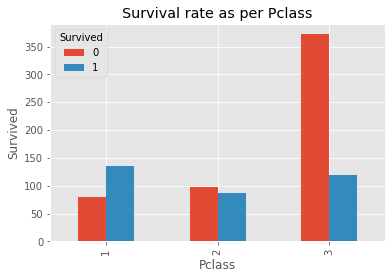

In [7]:
pd.crosstab(df_train.Pclass ,df_train.Survived).plot(kind='bar')
plt.title('Survival rate as per Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.show()

In [8]:
df_train['Age'].isna().sum()

177

**Filling Null values of age with 0.
Usually we don't do that but it seems to work fine for this**

In [9]:
df_train['Age'] = df_train['Age'].fillna(0)
df_train['Age'].isna().sum()

0

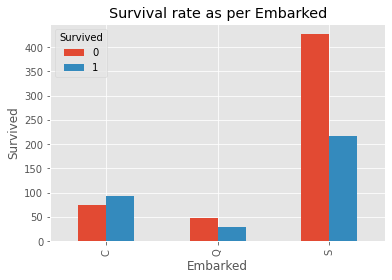

In [10]:
pd.crosstab(df_train.Embarked ,df_train.Survived).plot(kind='bar')
plt.title('Survival rate as per Embarked')
plt.xlabel('Embarked')
plt.ylabel('Survived')
plt.show()

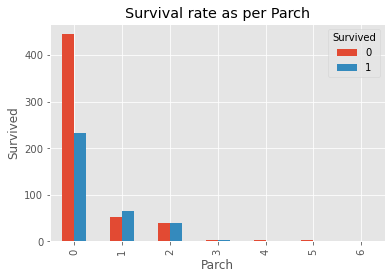

In [11]:
pd.crosstab(df_train.Parch ,df_train.Survived).plot(kind='bar')
plt.title('Survival rate as per Parch')
plt.xlabel('Parch')
plt.ylabel('Survived')
plt.show()

In [12]:
df_train.drop(columns = ['Name','Ticket' ,'Fare' , 'Cabin']  , inplace= True)

In [13]:
df_train.head(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1,0,3,male,22.0,1,0,S
1,2,1,1,female,38.0,1,0,C
2,3,1,3,female,26.0,0,0,S
3,4,1,1,female,35.0,1,0,S
4,5,0,3,male,35.0,0,0,S


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [15]:
cat_vars=['Sex' , 'Embarked']
for var in cat_vars:
    cat_list='var'+'_'+var
    cat_list = pd.get_dummies(df_train[var], prefix=var)
    df_train1=df_train.join(cat_list)
    df_train=df_train1

In [16]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Embarked', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [17]:
df_train.drop(columns = ['Sex','Embarked']  , inplace= True)
df_train.head(5)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,0,1,0,0,1
1,2,1,1,38.0,1,0,1,0,1,0,0
2,3,1,3,26.0,0,0,1,0,0,0,1
3,4,1,1,35.0,1,0,1,0,0,0,1
4,5,0,3,35.0,0,0,0,1,0,0,1


In [18]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Sex_female   891 non-null    uint8  
 7   Sex_male     891 non-null    uint8  
 8   Embarked_C   891 non-null    uint8  
 9   Embarked_Q   891 non-null    uint8  
 10  Embarked_S   891 non-null    uint8  
dtypes: float64(1), int64(5), uint8(5)
memory usage: 46.2 KB


In [19]:
s=0
d=0
for i in df_train['Survived']:
  if i==0:
    d+=1
  else:
    s+=1

print('Dead - ',d,' Survived -',s)

Dead -  549  Survived - 342


In [20]:
X = df_train.loc[:, df_train.columns != 'Survived']
Y = df_train.Survived

Modifying Test Data

In [21]:
df_test['Age'] = df_test['Age'].fillna(0)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [22]:
df_test.drop(columns = ['Name','Ticket' ,'Fare','Cabin']  , inplace= True)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Embarked     418 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 23.0+ KB


In [23]:
cat_vars=['Sex' , 'Embarked']
for var in cat_vars:
    cat_list='var'+'_'+var
    cat_list = pd.get_dummies(df_test[var], prefix=var)
    df_test1=df_test.join(cat_list)
    df_test=df_test1

In [24]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Embarked,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,male,34.5,0,0,Q,0,1,0,1,0
1,893,3,female,47.0,1,0,S,1,0,0,0,1
2,894,2,male,62.0,0,0,Q,0,1,0,1,0
3,895,3,male,27.0,0,0,S,0,1,0,0,1
4,896,3,female,22.0,1,1,S,1,0,0,0,1


In [25]:
df_test.drop(columns=['Sex' , 'Embarked'] , inplace=True)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Age          418 non-null    float64
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Sex_female   418 non-null    uint8  
 6   Sex_male     418 non-null    uint8  
 7   Embarked_C   418 non-null    uint8  
 8   Embarked_Q   418 non-null    uint8  
 9   Embarked_S   418 non-null    uint8  
dtypes: float64(1), int64(4), uint8(5)
memory usage: 18.5 KB


**Training**

In [26]:
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz # display the tree within a Jupyter notebook
from IPython.display import SVG
from graphviz import Source
from IPython.display import display
from ipywidgets import interactive, IntSlider, FloatSlider, interact
import ipywidgets
from IPython.display import Image
from subprocess import call
import matplotlib.image as mpimg

Here comes the interactive training part!!
You have to just slide to the values you want and the model will train for that values!

I noticed that the sliders are not visible while viewing, so if you want to check that out just press the copy and edit button on the top right hand corner.

Random Forest Training Accuracy: 0.808

Visualizing Decision Tree: 0


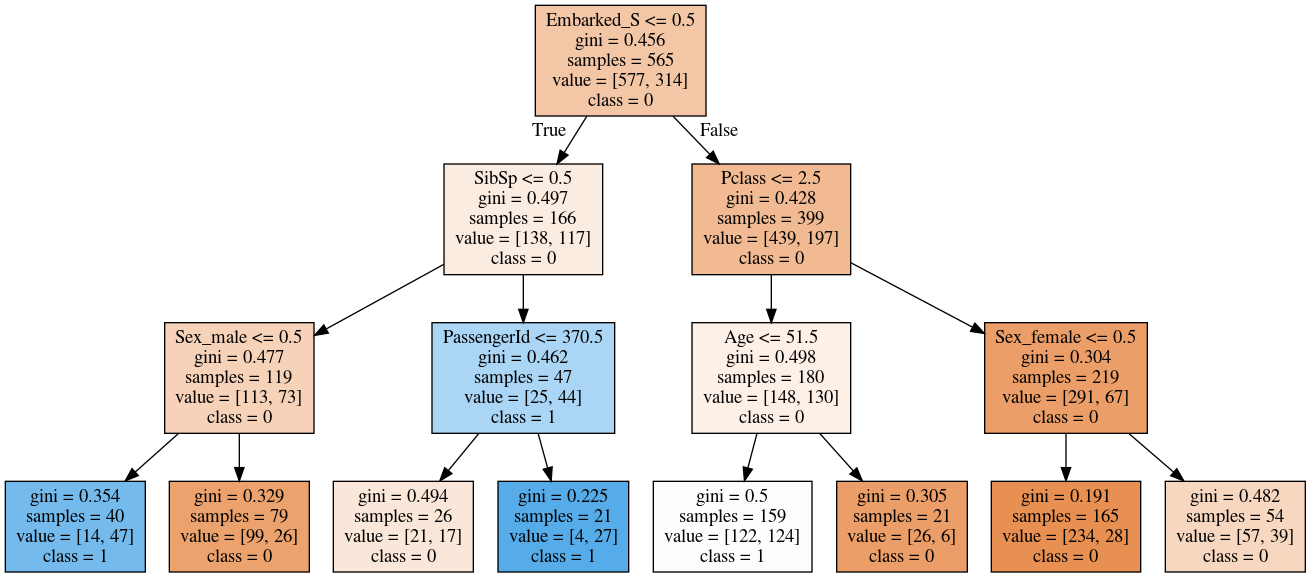

RandomForestClassifier(bootstrap='True', max_depth=3, n_jobs=-1, random_state=1,
                       verbose=False)

In [27]:
@interact
def plot_tree_rf(crit=["gini", "entropy"],
                 bootstrap=["True", "False"],
                 depth=IntSlider(min=1,max=30,value=3, continuous_update=False),
                 forests=IntSlider(min=1,max=200,value=100,continuous_update=False),
                 min_split=IntSlider(min=2,max=5,value=2, continuous_update=False),
                 min_leaf=IntSlider(min=1,max=5,value=1, continuous_update=False)):
    
    estimator = RandomForestClassifier(random_state=1,
                                       criterion=crit,
                                       bootstrap=bootstrap,
                                       n_estimators=forests,
                                       max_depth=depth,
                                       min_samples_split=min_split,
                                       min_samples_leaf=min_leaf,
                                       n_jobs=-1,
                                      verbose=False).fit(X, Y)

    print('Random Forest Training Accuracy: {:.3f}'.format(accuracy_score(Y, estimator.predict(X))))
    num_tree = estimator.estimators_[0]
    print('\nVisualizing Decision Tree:', 0)
    
    graph = Source(tree.export_graphviz(num_tree,
                                        out_file=None,
                                        feature_names=X.columns,
                                        class_names=['0', '1'],
                                        filled = True))
    
    display(Image(data=graph.pipe(format='png')))
    
    return estimator

Below I am using values which I have tested to get into top my best accuracy so far!!

Random Forest Training Accuracy: 0.899

Visualizing Decision Tree: 0


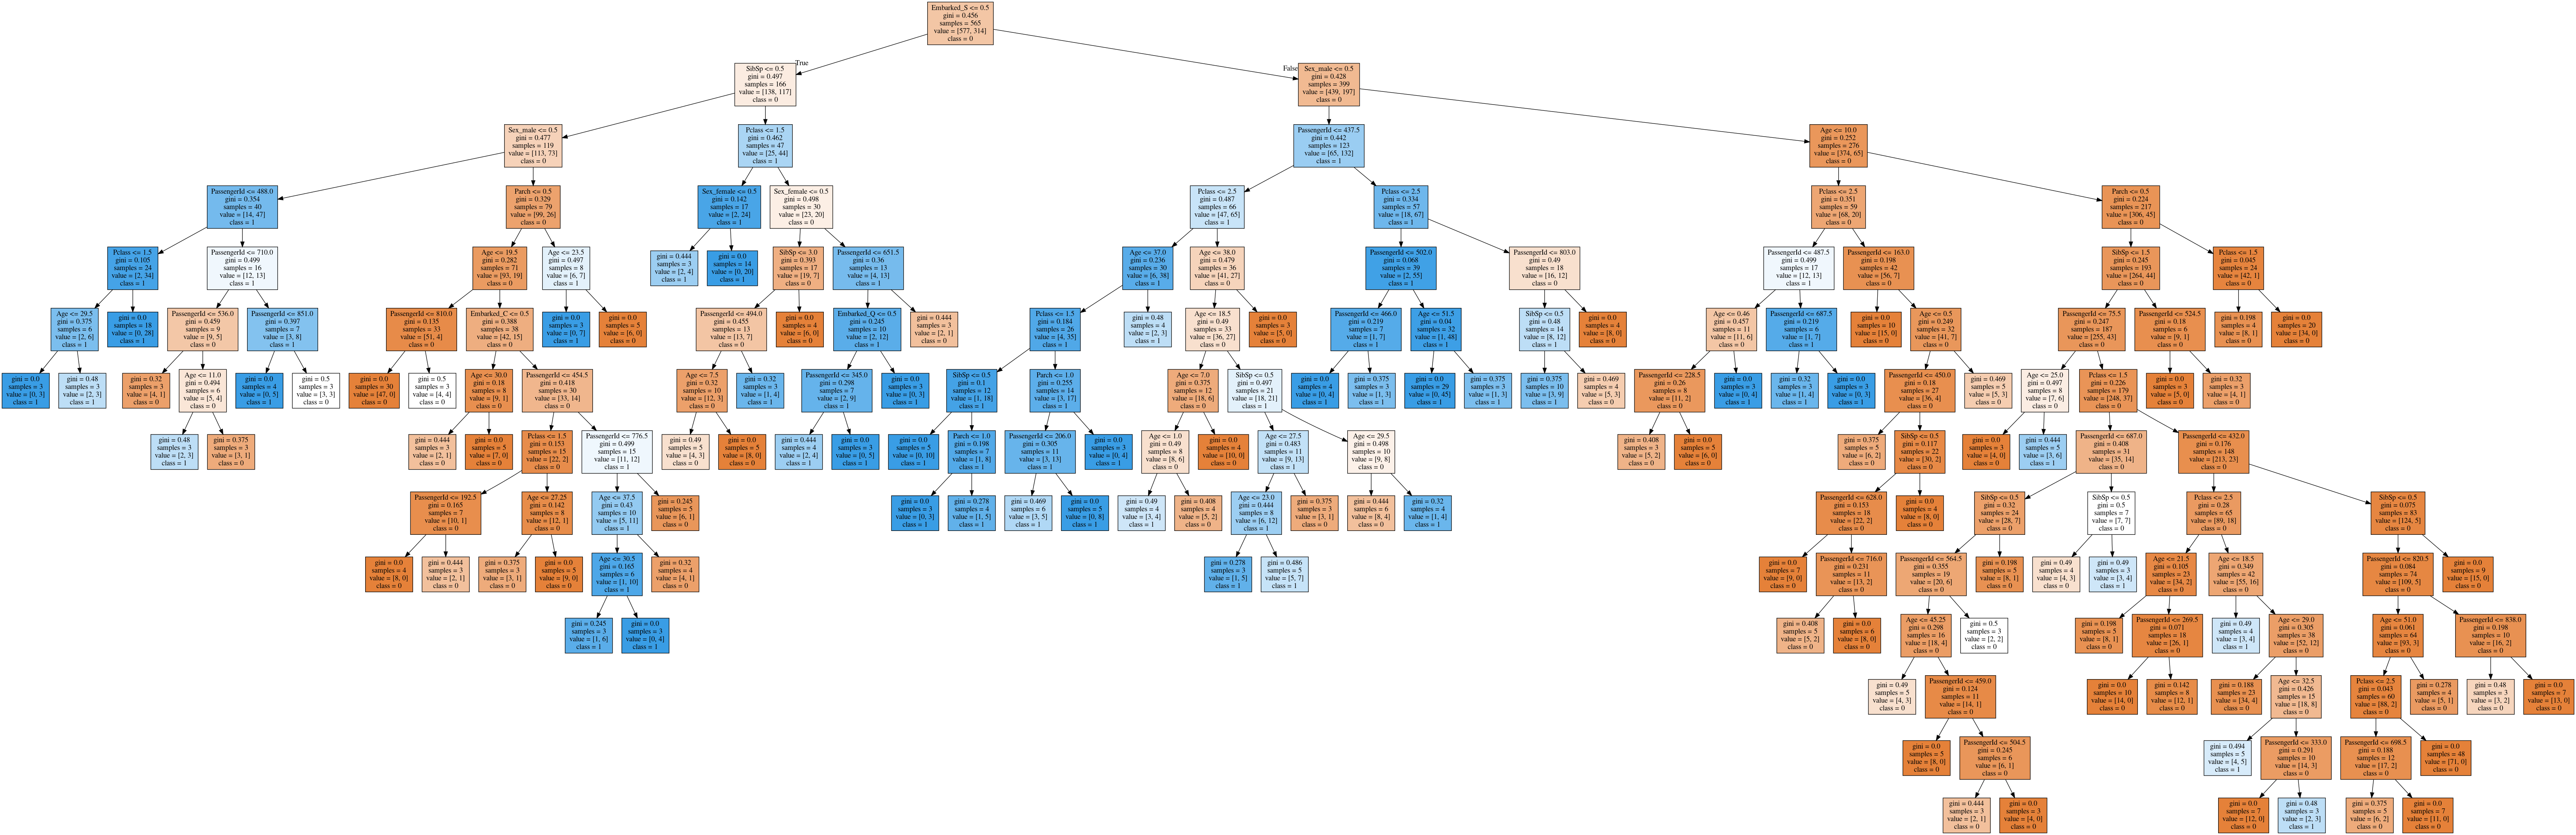

len 418


In [28]:
estimator = plot_tree_rf(crit='gini', bootstrap='False' , depth =16  , forests=100 , min_split=3 , min_leaf= 3)

y_pred_rf = estimator.predict(df_test)
print('len',len(y_pred_rf))

sub = pd.DataFrame(columns=['PassengerId' , 'Survived'])

sub['PassengerId'] = df_test['PassengerId'].astype(int)
sub['Survived'] = y_pred_rf.astype(int)

sub.to_csv('sub_rf.csv', index=False)